<a href="https://colab.research.google.com/github/LeeHJ030417/-/blob/main/ResNet_for_ImageNet_and_CIFAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# https://github.com/tony3ynot/ResNet-for-ImageNet-and-CIFAR/blob/main/ResNet.ipynb 참고
import torch
from torch import nn

1. Original ResNet (designed for ImageNet classification)

In [ ]:
class BasicBlock(nn.Module):
  expension=1
  def __init__(self, in_channels, inner_channels, stride=1, projection=None):
    super().__init__()

    self.residual=nn.Sequential(nn.Conv2d(in_channels, inner_channels, 3, stride=stride, padding=1, bias=False),
                                nn.BatchNorm2d(inner_channels),
                                nn.ReLU(inplace=True),
                                nn.Conv2d(inner_channels, inner_channels*self.expension, 3, padding=1, bias=False),
                                nn.BatchNorm2d(inner_channels))
    self.projection=projection
    self.relu=nn.ReLU(inplace=True)

  def forward(self, x):
    residual=self.residual(x)

    #projection shorout & identity shorout
    if self.projection is not None:
      shortcut=self.projection(x)
    else:
      shortcut=x

    out=self.relu(residual+shortcut)
    return out


#Bottleneck for ResNet-50/101/152
#downsampling stride at 3*3 convolution, instead of the first 1*1 convolution (original paper)
class Bottleneck(nn.Module):
  expansion=4
  def __init__(self, in_channels, inner_channels, stride=1, projection=None):
    super().__init__()

    #bottleneck sturcture
    self.residual=nn.Sequential(nn.Conv2d(in_channels, inner_channels, 1, bias=False),
                                nn.BatchNorm2d(inner_channels),
                                nn.ReLU(inplace=True),
                                nn.Conv2d(inner_channels, inner_channels, 3, stride=stride, padding=1, bias=False),
                                nn.BatchNorm2d(inner_channels),
                                nn.ReLU(inplace=True),
                                nn.Conv2d(inner_channels, inner_channels*self.expansion, 1, bias=False),
                                nn.BatchNorm2d(inner_channels*self.expansion))
    self.projection=projection
    self.relu=nn.ReLU(inplace=True)

  def forward(self, x):
    residual=self.residual(x)

    #projection shortcut & identity shortcut
    if self.projection is not None:
      shortcut=self.projection(x)
    else:
      shortcut=x

    out=self
    return out


#ResNet Architecture (ImageNet)
class ResNet(nn.Module):
  def __init__(self, block, num_block_list, num_classes=1000, zero_init_residual=True):
    super().__init__()

    self.in_channels=64

    self.conv1=nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
    self.bn1=nn.BatchNorm2d(64)
    self.relu=nn.ReLU(inplace=True)
    self.maxpool=nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
    self.stage1=self.make_stage(block, 64, num_block_list[0], stride=1)
    self.stage2=self.make_stage(block, 128, num_block_list[1], stride=2)
    self.stage3=self.make_stage(block, 256, num_block_list[2], stride=2)
    self.stage4=self.make_stage(block, 512, num_block_list[3], stride=2)
    self.avgpool=nn.AdaptiveAvgPool2d((1,1))
    self.fc=nn.Linear(512*block.expansion, num_classes)

    #weight initialization
    for m in self.modules():
      if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')

    #zero-initialize the last BN in each residual branch
    if zero_init_residual:
      for m in self.modules():
        if isinstance(m, Bottleneck):
          nn.init.constant_(m.residual[-1].weight, 0)


  def make_stage(self, block, inner_channels, num_blocks, stride=1):
    #projection shortcut when downsampling/dimension-matching
    if stride != 1 or self.in_channels != inner_channels*block.expansion:
      projection=nn.Sequential(
          nn.Conv2d(self.in_channels, inner_channels*block.expansion, 1, stride=stride, bias=False),
          nn.BatchNorm2d(inner_channels*block.expansion)
      )
    #identify shorcut otherwise
    else:
      projection=None

    layers=[]
    layers += [block(self.in_channels, inner_channels, stride, projection)] #projection only in the first block
    self.in_channels=inner_channels*block.expansion

    for _ in range(1, num_blocks):
      layers+=[block(self.in_channels, inner_channels)]

    return nn.Sequential(*layers)

  def forward(self, x):
    x=self.conv1(x)
    x=self.bn1(x)
    x=self.relu(x)
    x=self.maxpool(x)

    x=self.stage1(x)
    x=self.stage2(x)
    x=self.stage3(x)
    x=self.stage4(x)

    x=self.avgpool(x)
    x=torch.flatten(x, 1)
    x=self.fc(x)
    return x

In [ ]:
#ResNet Models
def resnet18(**kwargs):
  return ResNet(BasicBlock, [2,2,2,2], **kwargs)

def resnet34(**kwargs):
  return ResNet(BasicBlock, [3,4,6,3], **kwargs)

def resnet50(**kwargs):
  return ResNet(Bottleneck, [3,4,6,3], **kwargs)

def resnet101(**kwargs):
  return ResNet(Bottleneck, [3,4,23,3], **kwargs)

def resnet152(**kwargs):
  return ResNet(Bottleneck, [3,8,36,3], **kwargs)

2. Modified ResNet (designed for CIFAR-10/100 dataset)

In [ ]:
#Only use Basic Block for CIFAR-10/100
class BasicBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride=1, projection=None):
    super().__init__()
    self.residual=nn.Sequential(nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False),
                                nn.BatchNorm2d(out_channels),
                                nn.ReLU(inplace=True),
                                nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
                                nn.BatchNorm2d(out_channels))
    self.shortcut=projection
    self.relu=nn.ReLU(inplace=True)

  def forward(self, x):
    residual=self.residual(x)

    if self.shortcut is not None:
      shortcut=self.shortcut(x)
    else:
      shortcut=x

    out=self.relu(residual+shortcut)
    return out


#ResNet Architecture(CIFAR-10)
class ResNet_c(nn.Module):
  def __init__(self, block, num_block_list, num_classes=10): #num_classes=100
    super().__init__()

    self.in_channels=16

    #change on the first conv layer(output dim=16, kernel size=3)
    self.conv1=nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
    self.bn1=nn.BatchNorm2d(16)
    self.relu=nn.ReLU(inplace=True)

    #3 stages
    #feature map size = 32*32*16
    self.stage1=self.make_stage(block, 16, num_block_list[0], stride=1)
    #feature map size=16*16*32
    self.stage2=self.make_stage(block, 32, num_block_list[1], stride=2)
    #feature map size=8*8*64
    self.stage3=self.make_stage(block, 64, num_block_list[2], stride=2)

    self.avgpool=nn.AdaptiveAvgPool2d((1,1))
    self.fc=nn.Linear(64, num_classes)

    #Weight initialization
    for m in self.modules():
      if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
      elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)


  def make_stage(self, block, out_channels, num_blocks, stride=1):
    #projection shortcut when downsampling/dimension-matching
    if stride != 1 or self.in_channels != out_channels:
      projection=nn.Sequential(
          nn.Conv2d(self.in_channels, out_channels, 1, stride=stride, bias=False),
          nn.BatchNorm2d(out_channels))
    #identity shortcut otherwise
    else:
      projection=None

    layers=[block(self.in_channels, out_channels, stride, projection)] #projection only in the first block
    self.in_channels=out_channels

    for _ in range(1, num_blocks):
      layers+=[block(self.in_channels, out_channels)]

    return nn.Sequential(*layers)

  def forward(self, x):
    x=self.conv1(x)
    x=self.bn1(x)
    x=self.relu(x)

    x=self.stage1(x)
    x=self.stage2(x)
    x=self.stage3(x)

    x=self.avgpool(x)
    x=torch.flatten(x, 1)
    x=self.fc(x)

    return x

In [ ]:
#ResNet models (CIFAR-10)
def resnet20():
  return ResNet_c(BasicBlock, [3,3,3])

def resnet32():
  return ResNet_c(BasicBlock, [5,5,5])

def resnet44():
  return ResNet_c(BasicBlock, [7,7,7])

def resnet56():
  return ResNet_c(BasicBlock, [9,9,9])

def resnet110():
  return ResNet_c(BasicBlock, [18,18,18])

def resnet1202():
  return ResNet_c(BasicBlock, [200,200,200])

## 3. CIFAR-10 데이터셋 로드 및 전처리

In [ ]:
import torchvision
import torchvision.transforms as transforms

# 데이터 전처리를 위한 변환 정의
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # 이미지 픽셀 값을 [-1, 1] 범위로 정규화
])

# CIFAR-10 훈련 데이터셋 로드
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

# CIFAR-10 테스트 데이터셋 로드
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

# 데이터 로더 정의
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64,
                                          shuffle=True, num_workers=2)

testloader = torch.utils.data.DataLoader(testset, batch_size=64,
                                         shuffle=False, num_workers=2)

# CIFAR-10 클래스 이름
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"훈련 데이터셋 크기: {len(trainset)}")
print(f"테스트 데이터셋 크기: {len(testset)}")

100%|██████████| 170M/170M [00:03<00:00, 47.0MB/s]


훈련 데이터셋 크기: 50000
테스트 데이터셋 크기: 10000


## 4. 모델 정의, 손실 함수 및 옵티마이저 설정

In [ ]:
import torch
from torch import nn
import torch.optim as optim

# GPU 사용 가능 여부 확인
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ResNet20 모델 인스턴스화 (CIFAR-10용)
# resnet20 함수는 이전에 정의된 ResNet_c 클래스를 사용하여 모델을 생성합니다.
net = resnet20()
net.to(device)

# 손실 함수 및 옵티마이저 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

print("ResNet20 모델과 손실 함수, 옵티마이저 설정이 완료되었습니다.")

Using device: cuda:0
ResNet20 모델과 손실 함수, 옵티마이저 설정이 완료되었습니다.


## 5. 모델 학습

In [ ]:
num_epochs = 20

for epoch in range(num_epochs):  # 에포크 수만큼 반복
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # 입력 데이터와 라벨 가져오기
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # 옵티마이저의 변화도(gradient)를 0으로 초기화
        optimizer.zero_grad()

        # 순전파 + 역전파 + 최적화
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # 통계 출력
        running_loss += loss.item()
        if i % 100 == 99:    # 100 미니배치마다 출력
            print(f'Epoch [{epoch + 1}/{num_epochs}], Batch [{i + 1}/{len(trainloader)}], Loss: {running_loss / 100:.3f}')
            running_loss = 0.0

print('Finished Training')

# 모델 저장 (선택 사항)
# PATH = './cifar_net.pth'
# torch.save(net.state_dict(), PATH)
print("모델 학습이 완료되었습니다. 다음으로 모델을 평가하고 시각화할 수 있습니다.")

Epoch [1/20], Batch [100/782], Loss: 2.014
Epoch [1/20], Batch [200/782], Loss: 1.705
Epoch [1/20], Batch [300/782], Loss: 1.610
Epoch [1/20], Batch [400/782], Loss: 1.510
Epoch [1/20], Batch [500/782], Loss: 1.414
Epoch [1/20], Batch [600/782], Loss: 1.351
Epoch [1/20], Batch [700/782], Loss: 1.305
Epoch [2/20], Batch [100/782], Loss: 1.174
Epoch [2/20], Batch [200/782], Loss: 1.104
Epoch [2/20], Batch [300/782], Loss: 1.088
Epoch [2/20], Batch [400/782], Loss: 1.068
Epoch [2/20], Batch [500/782], Loss: 1.023
Epoch [2/20], Batch [600/782], Loss: 1.010
Epoch [2/20], Batch [700/782], Loss: 0.989
Epoch [3/20], Batch [100/782], Loss: 0.920
Epoch [3/20], Batch [200/782], Loss: 0.901
Epoch [3/20], Batch [300/782], Loss: 0.906
Epoch [3/20], Batch [400/782], Loss: 0.866
Epoch [3/20], Batch [500/782], Loss: 0.871
Epoch [3/20], Batch [600/782], Loss: 0.838
Epoch [3/20], Batch [700/782], Loss: 0.831
Epoch [4/20], Batch [100/782], Loss: 0.759
Epoch [4/20], Batch [200/782], Loss: 0.779
Epoch [4/20

## 6. 모델 평가 및 시각화

In [ ]:
correct = 0
total = 0
# 모델 평가 시에는 gradient 계산을 비활성화
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        # 모델에 이미지 전달하여 예측값 얻기
        outputs = net(images)
        # 가장 높은 값을 가진 클래스가 예측 클래스
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'테스트 세트의 이미지 10000개에 대한 정확도: {100 * correct / total:.2f}%')


테스트 세트의 이미지 10000개에 대한 정확도: 80.15%


### 몇 가지 예측 결과 시각화

정답:  cat   ship  ship  plane
예측:  cat   ship  ship  plane


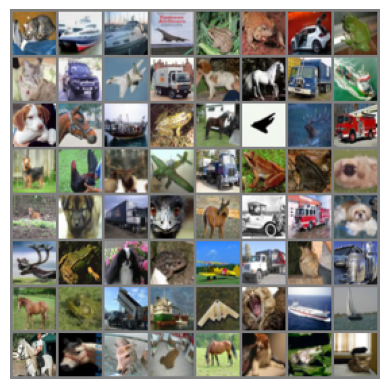

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# 테스트 데이터셋에서 이미지 배치를 가져오기
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# 모델 예측
outputs = net(images)
_, predicted = torch.max(outputs, 1)

print('정답: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))
print('예측: ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(4)))

# 이미지 출력
imshow(torchvision.utils.make_grid(images.cpu()))
